# 03 — Baseline Models

Reference scores for later work to beat. Three models with default settings, trained on the 165 raw features
(labeled rows only), each with and without class weighting. All use the temporal split from notebook 02
(fit 1–24, validate 25–35).

In [1]:
import sys
from datetime import date
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score
from lightgbm import LGBMClassifier

from src.data import (load_train, load_test, labeled, save_submission, load_sample_submission,
                      FEATURE_COLS, TIME_COL, LABEL_COL, SEED)
from src.validation import evaluate, log_experiment, TRAIN_END, VAL_END

TODAY = date.today().isoformat()
NOTEBOOK = "03_baseline_models"

C_UNW, C_W, C_MUTED = "#2a78d6", "#eb6834", "#898781"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": C_MUTED, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})

train = load_train()
test = load_test()
print("train:", train.shape, "| test:", test.shape)

train: (141772, 168) | test: (15329, 168)


## 1. The models

- **Logistic Regression:** a simple linear model, with features standardised first.
- **Random Forest:** many decision trees averaged together. Captures non-linear patterns.
- **LightGBM:** gradient-boosted trees, usually the strongest on tabular data.

**Class weighting:** only 9% of fit rows are illicit. `class_weight="balanced"` makes errors on illicit rows count
about 10× more during training. AUC depends only on ranking, so we test whether this helps.

In [2]:
def make_models(class_weight):
    """The three baseline models with library-default settings, plus the class weighting being tested."""
    return {
        "logreg": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=SEED)),
        "rf": RandomForestClassifier(class_weight=class_weight, n_jobs=-1, random_state=SEED),
        "lgbm": LGBMClassifier(class_weight=class_weight, random_state=SEED, verbose=-1),
    }

NAMES = {"logreg": "Logistic Regression", "rf": "Random Forest", "lgbm": "LightGBM"}
WEIGHTINGS = {"none": None, "balanced": "balanced"}

## 2. Validation results

In [3]:
results = {}
for w_name, w in WEIGHTINGS.items():
    for m_name, model in make_models(w).items():
        res = evaluate(model, FEATURE_COLS, train)
        results[(m_name, w_name)] = res
        print(f"{NAMES[m_name]:20s} class_weight={w_name:8s} pooled AUC = {res['overall_auc']:.4f}   "
              f"per-step mean = {res['mean_step_auc']:.4f} (std {res['std_step_auc']:.4f})")

Logistic Regression  class_weight=none     pooled AUC = 0.8863   per-step mean = 0.9149 (std 0.0737)


Random Forest        class_weight=none     pooled AUC = 0.9939   per-step mean = 0.9931 (std 0.0072)


LightGBM             class_weight=none     pooled AUC = 0.9960   per-step mean = 0.9949 (std 0.0048)


Logistic Regression  class_weight=balanced pooled AUC = 0.8856   per-step mean = 0.9130 (std 0.0686)


Random Forest        class_weight=balanced pooled AUC = 0.9965   per-step mean = 0.9959 (std 0.0044)


LightGBM             class_weight=balanced pooled AUC = 0.9962   per-step mean = 0.9946 (std 0.0060)


Besides AUC, the table shows **average precision** (precision–recall area; a random model scores ≈ 0.19 here) and
**precision / recall / F1** when every row scoring ≥ 0.5 is flagged as illicit.

In [4]:
rows = []
for (m_name, w_name), res in results.items():
    vp = res["val_pred"]
    y, p = vp[LABEL_COL], vp["pred"]
    flag = (p >= 0.5).astype(int)
    rows.append({
        "model": NAMES[m_name], "class_weight": w_name,
        "pooled AUC": res["overall_auc"],
        "mean step AUC": res["mean_step_auc"], "std step AUC": res["std_step_auc"],
        "min step AUC": res["per_step"].auc.min(),
        "avg precision": average_precision_score(y, p),
        "precision@0.5": precision_score(y, flag, zero_division=0),
        "recall@0.5": recall_score(y, flag),
        "F1@0.5": f1_score(y, flag),
    })
summary = pd.DataFrame(rows).sort_values("pooled AUC", ascending=False).reset_index(drop=True)
summary.round(4)

,model,class_weight,pooled AUC,mean step AUC,std step AUC,min step AUC,avg precision,precision@0.5,recall@0.5,F1@0.5
0,Random Forest,balanced,0.9965,0.9959,0.0044,0.9856,0.9883,0.9832,0.9060,0.9430
1,LightGBM,balanced,0.9962,0.9946,0.0060,0.9841,0.9865,0.9561,0.9467,0.9513
2,LightGBM,none,0.9960,0.9949,0.0048,0.9867,0.9860,0.9804,0.9144,0.9463
3,Random Forest,none,0.9939,0.9931,0.0072,0.9759,0.9848,0.9880,0.9242,0.9550
4,Logistic Regression,none,0.8863,0.9149,0.0737,0.7366,0.5568,0.4915,0.7719,0.6006
5,Logistic Regression,balanced,0.8856,0.9130,0.0686,0.7504,0.5276,0.3856,0.9642,0.5509


In [5]:
# AUC for every validation step, one column per configuration
per_step_table = pd.DataFrame({
    f"{m}/{w}": res["per_step"].auc for (m, w), res in results.items()
})
per_step_table.insert(0, "n_illicit", next(iter(results.values()))["per_step"].n_illicit)
per_step_table.round(3)

,n_illicit,logreg/none,rf/none,lgbm/none,logreg/balanced,rf/balanced,lgbm/balanced
time_step,,,,,,,
25,118,0.971,0.999,1.000,0.965,1.000,1.000
26,96,0.887,0.976,0.988,0.892,0.986,0.989
27,24,0.979,0.996,1.000,0.978,0.999,0.999
28,85,0.984,1.000,1.000,0.980,1.000,1.000
29,329,0.918,0.995,0.995,0.920,0.996,0.996
30,83,0.953,0.985,0.989,0.951,0.992,0.984
31,106,0.737,0.992,0.987,0.750,0.995,0.984
32,342,0.836,1.000,0.998,0.839,0.999,0.999
33,23,0.951,0.994,0.995,0.950,0.993,0.995


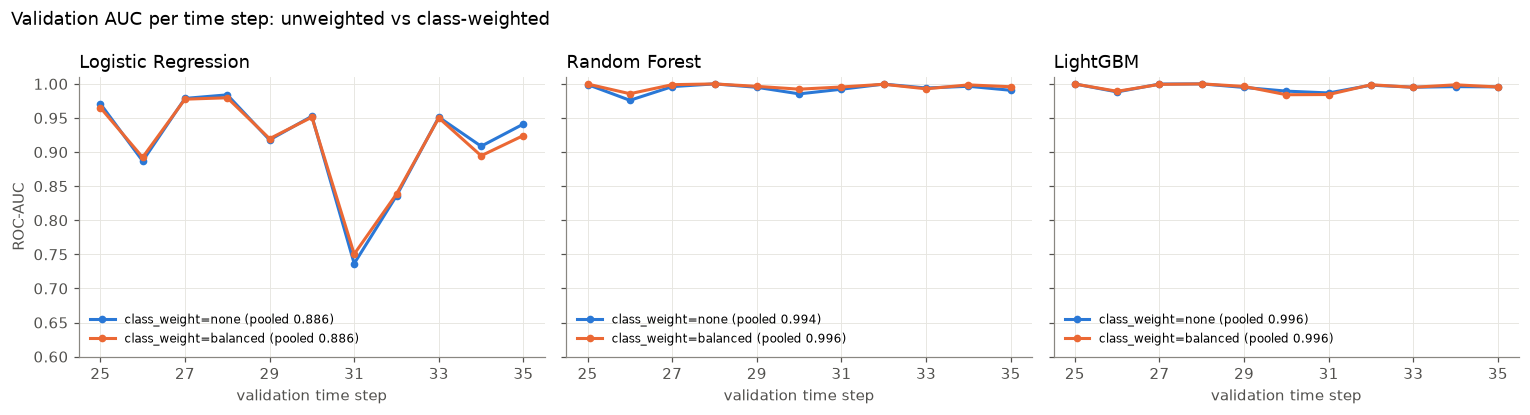

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
steps = per_step_table.index
for ax, m_name in zip(axes, NAMES):
    for w_name, color in [("none", C_UNW), ("balanced", C_W)]:
        res = results[(m_name, w_name)]
        ax.plot(steps, res["per_step"].auc, marker="o", ms=4, lw=2, color=color,
                label=f"class_weight={w_name} (pooled {res['overall_auc']:.3f})")
    ax.set_title(NAMES[m_name], loc="left")
    ax.set_xticks(steps[::2]); ax.set_xlabel("validation time step")
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.6, 1.01)
fig.suptitle("Validation AUC per time step: unweighted vs class-weighted", x=0.01, ha="left")
plt.tight_layout(); plt.show()

### Leakage check

The trees score far above logistic regression. If a single feature were a near-copy of the label, it would score
close to 1 on its own. We check that here.

In [7]:
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from src.validation import temporal_split

fit, val = temporal_split(train)

# AUC of each raw feature used directly as a score (direction-free: max(AUC, 1 - AUC))
single = pd.Series({c: roc_auc_score(val[LABEL_COL], val[c]) for c in FEATURE_COLS})
single = np.maximum(single, 1 - single).sort_values(ascending=False)
print("best single features (val AUC):", single.head(5).round(3).to_dict())

# Small decision trees on all features
for depth in [1, 2, 3, 5]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(fit[FEATURE_COLS], fit[LABEL_COL])
    print(f"decision tree depth {depth}: val AUC = {roc_auc_score(val[LABEL_COL], tree.predict_proba(val[FEATURE_COLS])[:, 1]):.3f}")

best single features (val AUC): {'feat_76': 0.795, 'feat_144': 0.793, 'feat_58': 0.791, 'feat_64': 0.791, 'feat_5': 0.786}
decision tree depth 1: val AUC = 0.750


decision tree depth 2: val AUC = 0.784


decision tree depth 3: val AUC = 0.825


decision tree depth 5: val AUC = 0.844


No single feature beats about 0.8, and a depth-5 tree reaches 0.84. The signal comes from many features combined,
not from a leaked column.

## 3. Log results to `experiments.csv`

Re-running updates the existing rows rather than adding duplicates.

In [8]:
for (m_name, w_name), res in results.items():
    log_experiment(
        date=TODAY, notebook=NOTEBOOK,
        change=f"Baseline {NAMES[m_name]}, raw 165 features, class_weight={w_name}",
        val_auc=res["overall_auc"],
        notes=(f"fit steps 1-{TRAIN_END}, val {TRAIN_END + 1}-{VAL_END}; mean step AUC {res['mean_step_auc']:.4f} "
               f"(std {res['std_step_auc']:.4f}, min {res['per_step'].auc.min():.4f}); default hyperparameters"),
    )
pd.read_csv(ROOT / "experiments.csv")

,date,notebook,change,val_auc,public_lb_auc,notes
0,2026-10-03,03_baseline_models,SUBMISSION Random Forest class_weight=balanced...,0.9965,NaN,file submissions/2026-10-03_rf_balanced_baseli...
1,2026-10-03,03_baseline_models,"Baseline Logistic Regression, raw 165 features...",0.8863,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.914..."
2,2026-10-03,03_baseline_models,"Baseline Random Forest, raw 165 features, clas...",0.9939,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.993..."
3,2026-10-03,03_baseline_models,"Baseline LightGBM, raw 165 features, class_wei...",0.9960,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.994..."
4,2026-10-03,03_baseline_models,"Baseline Logistic Regression, raw 165 features...",0.8856,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.913..."
5,2026-10-03,03_baseline_models,"Baseline Random Forest, raw 165 features, clas...",0.9965,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.995..."
6,2026-10-03,03_baseline_models,"Baseline LightGBM, raw 165 features, class_wei...",0.9962,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.994..."


## 4. Pick the best configuration

Rule: highest pooled validation AUC, the same measure Kaggle uses.

In [9]:
best_key = max(results, key=lambda k: results[k]["overall_auc"])
best_model_name, best_weight = best_key
print(f"best: {NAMES[best_model_name]} with class_weight={best_weight}, "
      f"pooled val AUC = {results[best_key]['overall_auc']:.4f}")

best: Random Forest with class_weight=balanced, pooled val AUC = 0.9965


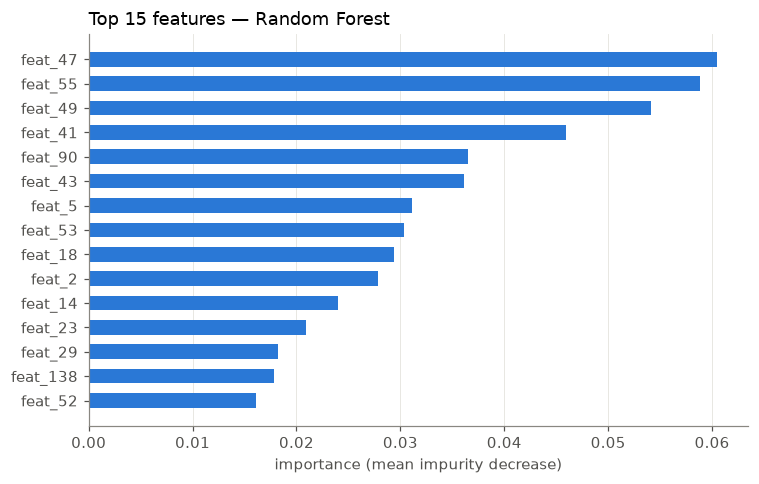

In [10]:
# Which features does the best model rely on? (Only defined for the tree models.)
best_fitted = results[best_key]["model"]
if hasattr(best_fitted, "feature_importances_"):
    imp = pd.Series(best_fitted.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    top = imp.head(15)[::-1]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.barh(top.index, top.values, color=C_UNW, height=0.6)
    ax.set_xlabel("importance (" + ("split count" if best_model_name == "lgbm" else "mean impurity decrease") + ")")
    ax.set_title(f"Top 15 features — {NAMES[best_model_name]}", loc="left")
    ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show()

## 5. Retrain on steps 1–35 and predict the test set

The chosen configuration is refit on all labeled training rows, so it learns from the most recent steps.

In [11]:
full = labeled(train)
final_model = make_models(WEIGHTINGS[best_weight])[best_model_name]
final_model.fit(full[FEATURE_COLS], full[LABEL_COL])
print(f"refit {NAMES[best_model_name]} on {len(full)} labeled rows (steps {full[TIME_COL].min()}-{full[TIME_COL].max()}), "
      f"{full[LABEL_COL].sum()} illicit")

test_pred = final_model.predict_proba(test[FEATURE_COLS])[:, 1]

refit Random Forest on 31235 labeled rows (steps 1-35), 3644 illicit


In [12]:
# Quick sanity look at the test predictions: share of rows the model scores >= 0.5, per test step.
# (Test labels are hidden, so this is only a plausibility check.)
(pd.DataFrame({TIME_COL: test[TIME_COL], "pred": test_pred})
   .groupby(TIME_COL)["pred"]
   .agg(n="size", mean_score="mean", share_flagged=lambda p: (p >= 0.5).mean())
   .round(3).T)

time_step,36,37,38,39,40,41,42,43,44,45,46,47,48,49
n,1708.000,498.000,756.000,1183.000,1211.000,1132.000,2154.000,1370.000,1591.000,1221.000,712.000,846.000,471.000,476.000
mean_score,0.057,0.076,0.152,0.090,0.113,0.127,0.127,0.063,0.073,0.068,0.045,0.045,0.034,0.050
share_flagged,0.019,0.054,0.134,0.063,0.056,0.095,0.089,0.000,0.005,0.002,0.003,0.001,0.000,0.002


## 6. Save the submission

`save_submission` checks the file against `sample_submission.csv` (columns, row count, index order, values in [0, 1])
and writes nothing if a check fails.

In [13]:
suffix = "" if best_weight == "none" else f"_{best_weight}"
filename = f"{TODAY}_{best_model_name}{suffix}_baseline.csv"
path = save_submission(test, test_pred, filename)
print("saved:", path.relative_to(ROOT))

# Read it back and compare with the sample once more
saved, sample = pd.read_csv(path), load_sample_submission()
print("columns:", list(saved.columns), "| rows:", len(saved), "| matches sample index:", saved["index"].equals(sample["index"]))
saved.head()

saved: submissions/2026-10-03_rf_balanced_baseline.csv
columns: ['index', 'target'] | rows: 15329 | matches sample index: True


,index,target
0,0,0.00
1,1,0.05
2,2,0.01
3,3,0.02
4,4,0.04


In [14]:
log_experiment(
    date=TODAY, notebook=NOTEBOOK,
    change=f"SUBMISSION {NAMES[best_model_name]} class_weight={best_weight}, refit on steps 1-35",
    val_auc=results[best_key]["overall_auc"],
    notes=f"file submissions/{filename}; val AUC is from the 1-{TRAIN_END} -> {TRAIN_END + 1}-{VAL_END} split; fill public_lb_auc after submitting",
)
pd.read_csv(ROOT / "experiments.csv").tail(3)

,date,notebook,change,val_auc,public_lb_auc,notes
4,2026-10-03,03_baseline_models,"Baseline Random Forest, raw 165 features, clas...",0.9965,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.995..."
5,2026-10-03,03_baseline_models,"Baseline LightGBM, raw 165 features, class_wei...",0.9962,NaN,"fit steps 1-24, val 25-35; mean step AUC 0.994..."
6,2026-10-03,03_baseline_models,SUBMISSION Random Forest class_weight=balanced...,0.9965,NaN,file submissions/2026-10-03_rf_balanced_baseli...


## Summary

| Model | Unweighted | Balanced |
|---|---|---|
| Logistic Regression | 0.886 | 0.886 |
| Random Forest | 0.994 | **0.9965** |
| LightGBM | 0.996 | 0.996 |

*Pooled validation AUC (fit 1–24, validate 25–35).*

- **Trees beat the linear model** by a wide margin and are more stable over time (worst step ≈ 0.98 vs 0.74).
- **Class weighting barely changes AUC.** It mainly shifts precision and recall.
- **Random Forest (balanced) was submitted**, but it is effectively tied with LightGBM.
- **Public leaderboard: 0.934**, well below validation. Almost no test rows from step 43 onwards are flagged.
  This is likely the known shift in the Elliptic data around that step, which our validation window (25–35)
  cannot see. Improving generalisation past step 43 is the next goal.